In [1]:
import pandas as pd
df = pd.read_csv('C:/Users/priya/Downloads/archive (6)/HREmployee_data.csv')
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,JobInvolvement,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,31,No,Non-Travel,158,Software,7,3,3,Male,2,...,4,1,2,15,1,2,12,4,10,11
1,38,No,Travel_Rarely,985,Human Resources,33,5,1,Female,2,...,1,3,4,5,4,3,1,1,1,1
2,59,Yes,Non-Travel,1273,Sales,5,2,4,Female,1,...,3,2,2,9,5,1,6,6,4,3
3,52,Yes,Travel_Rarely,480,Support,2,5,4,Female,2,...,3,2,2,22,4,4,10,9,5,6
4,32,No,Non-Travel,543,Human Resources,7,5,2,Male,3,...,3,4,2,30,3,4,29,27,9,7


In [2]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       50000 non-null  int64 
 1   Attrition                 50000 non-null  object
 2   BusinessTravel            50000 non-null  object
 3   DailyRate                 50000 non-null  int64 
 4   Department                50000 non-null  object
 5   DistanceFromHome          50000 non-null  int64 
 6   Education                 50000 non-null  int64 
 7   EnvironmentSatisfaction   50000 non-null  int64 
 8   Gender                    50000 non-null  object
 9   JobInvolvement            50000 non-null  int64 
 10  JobLevel                  50000 non-null  int64 
 11  JobRole                   50000 non-null  object
 12  JobSatisfaction           50000 non-null  int64 
 13  MaritalStatus             50000 non-null  object
 14  NumCompaniesWorked    

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EnvironmentSatisfaction     0
Gender                      0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [3]:
df['Attrition'].value_counts()
df['Department'].unique()


array(['Software', 'Human Resources', 'Sales', 'Support', 'Hardware',
       'Research & Development'], dtype=object)

In [4]:
#Data Preprocessing
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Attrition'] = label_encoder.fit_transform(df['Attrition'])  # Yes = 1, No = 0
# Do the same for other categorical columns if needed.


In [5]:
# List of columns to consider dropping if they exist
columns_to_drop = ['EmployeeID', 'Over18', 'EmployeeCount', 'StandardHours']

# Drop only if the column exists and has a single unique value (constant)
for col in columns_to_drop:
    if col in df.columns and df[col].nunique() == 1:
        df.drop(col, axis=1, inplace=True)
        print(f"Dropped column: {col}")


In [12]:
 print(df.columns.tolist())



['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [14]:
 df_encoded = pd.get_dummies(df, drop_first=True)  # Reapply encoding to ensure proper transformation
print(df_encoded.columns)  # Verify the columns again



Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition_Yes',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'Department_Software', 'Department_Support',
       'Gender_Male', 'JobRole_Healthcare Representative',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scientist',
       'JobRole_Sales Executive', 'JobRole_Sales Representative'

In [32]:
 import seaborn as sns
import matplotlib.pyplot as plt



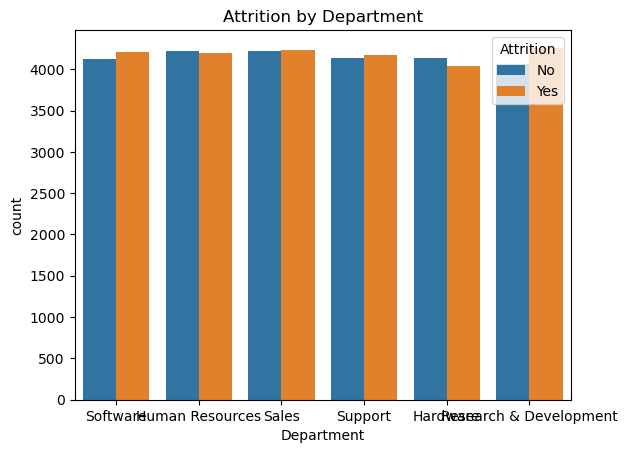

In [33]:
# Attrition by Department
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition by Department')
plt.show()

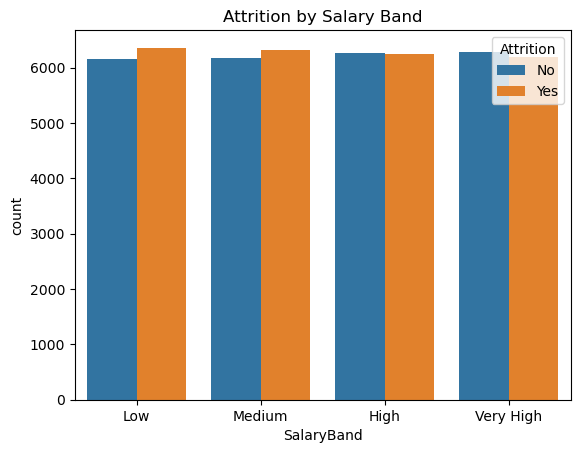

In [34]:
# Salary Band
df['SalaryBand'] = pd.qcut(df['DailyRate'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
sns.countplot(data=df, x='SalaryBand', hue='Attrition')
plt.title('Attrition by Salary Band')
plt.show()

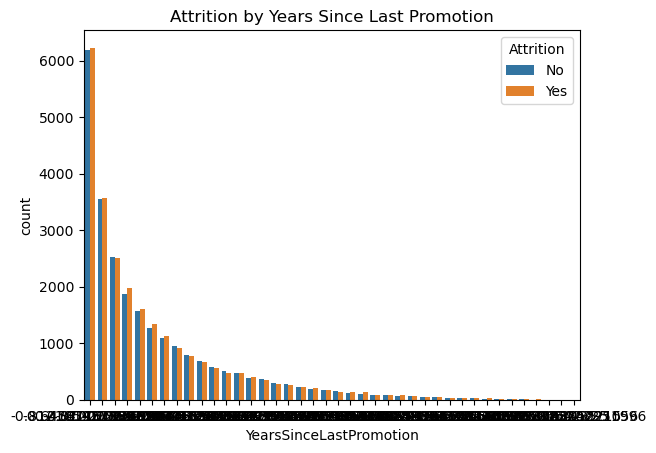

In [35]:
# Promotions
sns.countplot(data=df, x='YearsSinceLastPromotion', hue='Attrition')
plt.title('Attrition by Years Since Last Promotion')
plt.show()

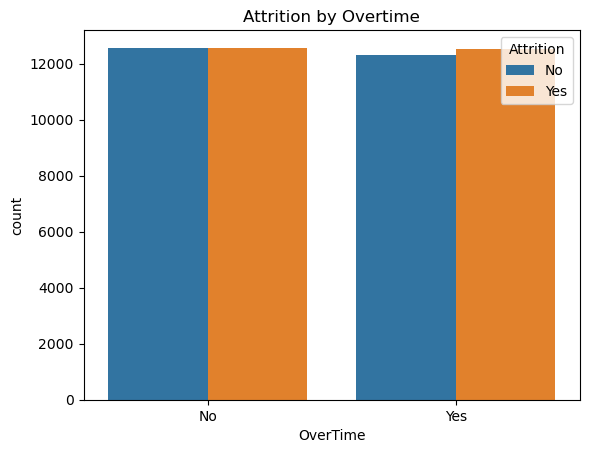

In [36]:
# Overtime
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Attrition by Overtime')
plt.show()


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load your data
df = pd.read_csv('C:/Users/priya/Downloads/archive (6)/HREmployee_data.csv')

# Encode the target
df['Attrition'] = LabelEncoder().fit_transform(df['Attrition'])  # Yes/No → 1/0

# Drop unnecessary columns
drop_cols = ['EmployeeID', 'Over18', 'EmployeeCount', 'StandardHours']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

# Encode categorical columns using get_dummies
categorical_cols = df.select_dtypes(include='object').columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Optional: create a salary band from numeric column (e.g., DailyRate)
df['SalaryBand'] = pd.qcut(df['DailyRate'], q=4, labels=False)

# Final features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [4]:
from sklearn.preprocessing import StandardScaler

# One-hot encode categoricals
X_encoded = pd.get_dummies(X, drop_first=True)

# Scale numeric columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Now split the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix:\n{cm}')

# Classification Report
report = classification_report(y_test, y_pred)
print(f'Classification Report:\n{report}')

# ROC-AUC (if it's a binary classification)
if len(set(y_test)) == 2:  # Binary classification check
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f'ROC AUC: {roc_auc:.4f}')

Accuracy: 0.5021
Confusion Matrix:
[[3980 3444]
 [4024 3552]]
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.54      0.52      7424
           1       0.51      0.47      0.49      7576

    accuracy                           0.50     15000
   macro avg       0.50      0.50      0.50     15000
weighted avg       0.50      0.50      0.50     15000

ROC AUC: 0.5040


In [7]:
print(X_test.shape)  # Check if X_test is defined
print(y_test.shape)  # Check if y_test is defined


(15000, 41)
(15000,)


In [16]:
pip install shap


   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.2 kB ? eta -:--:--
   ------------------- -------------------- 262.1/545.2 kB ? eta -:--:--
   ------------------- -------------------- 262.1/545.2 kB ? eta -:--:--
   ------------------- -------------------- 262.1/545.2 kB ? eta -:--:--
   ------------------- -------------------- 262.1/545.2 kB ? eta -:--:--
   -------------------------------------- 545.2/545.2 kB 393.7 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [17]:
!pip install shap


In [22]:
!pip install xgboost

In [25]:
import pandas as pd
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import matplotlib

# Use Agg backend if you're not in a graphical environment
matplotlib.use('Agg')

# Load your HR dataset
df = pd.read_csv('C:/Users/priya/Downloads/archive (6)/HREmployee_data.csv')

# Encode categorical variables
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Check for missing values
print(df.isnull().sum())  # Ensure there are no missing values

# Define features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the data types
print(X_train.dtypes)

# Train XGBoost classifier
model = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False)
model.fit(X_train, y_train)

# Evaluate the model
print("Model accuracy on test data:", model.score(X_test, y_test))

# Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# SHAP analysis
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Check if SHAP values are computed correctly
print("SHAP Values: ", shap_values)
print(f"SHAP values shape: {shap_values.shape}")

# SHAP summary plot
shap.summary_plot(shap_values, X_test)
plt.show()  # Display the plot

# Explain a single prediction (waterfall plot)
shap.plots.waterfall(shap_values[0])
plt.show()  # Display the waterfall plot


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EnvironmentSatisfaction     0
Gender                      0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64
Age                         int64
BusinessTravel              int32
DailyRate                   int64
Department                  int32
DistanceFromHome            int64
Educati

D:\python anaconda\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:34:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model accuracy on test data: 0.5013
              precision    recall  f1-score   support

           0       0.49      0.49      0.49      4931
           1       0.51      0.51      0.51      5069

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



 99%|===================| 9886/10000 [00:29<00:00]        

SHAP Values:  .values =
array([[-0.06119354, -0.0222311 ,  0.02800775, ...,  0.08585857,
        -0.07260386, -0.1161918 ],
       [ 0.01851347, -0.00481528, -0.29882887, ...,  0.00836388,
        -0.01766158, -0.07243134],
       [-0.03066978,  0.0289019 , -0.04094086, ...,  0.00721835,
        -0.02081488, -0.00763024],
       ...,
       [-0.023705  ,  0.01345035,  0.02783874, ...,  0.00627034,
         0.05900243,  0.03626098],
       [ 0.08894271,  0.01391999, -0.14841907, ...,  0.35072046,
         0.00245005,  0.25427776],
       [ 0.0570555 ,  0.01161911,  0.07825878, ...,  0.00584571,
         0.0242872 , -0.03744039]])

.base_values =
array([0.04669809, 0.04669809, 0.04669809, ..., 0.04669809, 0.04669809,
       0.04669809])

.data =
array([[  60,    0,  896, ...,    6,    2,    2],
       [  54,    1,  171, ...,    4,    3,   14],
       [  30,    2,  672, ...,    1,    1,    2],
       ...,
       [  53,    1,  936, ...,    2,    4,    1],
       [  53,    0, 1121, ...,   2

D:\python anaconda\Lib\site-packages\shap\plots\_beeswarm.py:1155: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  pl.show()
C:\Users\priya\AppData\Local\Temp\ipykernel_19720\4104947719.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()  # Display the plot
D:\python anaconda\Lib\site-packages\shap\plots\_waterfall.py:368: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\priya\AppData\Local\Temp\ipykernel_19720\4104947719.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()  # Display the waterfall plot
